In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" All imports done!")

 All imports done!


In [3]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

## 3. Text Preprocessor

Custom class that handles:
- Stripping MCQ-style prefixes (*"Pick the best answer: "*)
- Stripping suffixes (*"from the following options."*)
- Normalising whitespace and optional lowercasing

### 3.1 Class Definition

In [4]:
class TextPreprocessor:
    def __init__(self, lowercase=True):
        
        self.lowercase = lowercase
        
        # Common question prefixes (MCQ questions have these patterns)
        self.prefixes = [
            "pick the best possible answer",
            "pick the best answer",
            "identify the best answer",
            "identify the correct",
            "determine the best",
            "choose the best",
            "select the best",
            "which of the following",
        ]
        
        # Common suffixes are 
        self.suffixes = [
            "among the following options",
            "among the listed options",
            "from the following options",
            "from the following choices",
            "from the given options",
        ]
    
    def remove_prefix(self, text):
        """
        Remove common question prefixes
        Example: 'Pick the best answer: What is X?' → 'What is X?'
        """
        text_lower = text.lower().strip()
        
        for prefix in self.prefixes:
            if text_lower.startswith(prefix):
                # Remove prefix and following colon/space
                text = text[len(prefix):].strip()
                text = re.sub(r'^[:?\s]+', '', text)
                break
        
        return text
    
    def remove_suffix(self, text):
        """
        Remove common suffixes
        Example: 'What is X? from the following options.' → 'What is X?'
        """
        text_lower = text.lower().strip()
        
        for suffix in self.suffixes:
            if text_lower.endswith(suffix):
                # Remove suffix
                text = text[:-len(suffix)].strip()
                # Remove trailing punctuation
                text = re.sub(r'[\?\.:;\s]+$', '', text)
                break
        
        return text
    
    def clean_whitespace(self, text):
        text = re.sub(r'\s+', ' ', text)  # Multiple spaces to single
        text = text.strip()  # Remove leading/trailing
        return text
    
    def normalize_text(self, text):
        """
        Apply all cleaning steps in order
        Remove prefix --> Remove suffix --> Clean whitespace --> Lowercase
        """
        text = self.remove_prefix(text)
        text = self.remove_suffix(text)
        text = self.clean_whitespace(text)
        
        if self.lowercase:
            text = text.lower()
        
        return text

preprocessor = TextPreprocessor()
print("TextPreprocessor created ")

TextPreprocessor created 


In [5]:
train_clean = train_df.copy()
test_clean  = test_df.copy()

# clean prompts
train_clean['prompt'] = train_clean['prompt'].apply(preprocessor.normalize_text)
test_clean['prompt']  = test_clean['prompt'].apply(preprocessor.normalize_text)

# clean all five options
for col in ['A', 'B', 'C', 'D', 'E']:
    train_clean[col] = train_clean[col].apply(preprocessor.normalize_text)
    test_clean[col]  = test_clean[col].apply(preprocessor.normalize_text)

print('Preprocessing done.')
print(f'\nBefore: {train_df.iloc[0]["prompt"]}')
print(f'After : {train_clean.iloc[0]["prompt"]}')

Preprocessing done.

Before: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
After : what is martin heidegger's view on the relationship between time and human existence? among the listed options.


CREATE TEXT FEATURES

In [6]:
# Calculate text lengths for TRAIN
train_clean['prompt_len'] = train_clean['prompt'].apply(len)
train_clean['prompt_words'] = train_clean['prompt'].apply(lambda x: len(x.split()))

for col in ['A', 'B', 'C', 'D', 'E']:
    train_clean[f'{col}_len'] = train_clean[col].apply(len)
    train_clean[f'{col}_words'] = train_clean[col].apply(lambda x: len(x.split()))


In [7]:
# Same for TEST
test_clean['prompt_len'] = test_clean['prompt'].apply(len)
test_clean['prompt_words'] = test_clean['prompt'].apply(lambda x: len(x.split()))

for col in ['A', 'B', 'C', 'D', 'E']:
    test_clean[f'{col}_len'] = test_clean[col].apply(len)
    test_clean[f'{col}_words'] = test_clean[col].apply(lambda x: len(x.split()))

print("Text features created")

Text features created


TEXT STATISTICS

In [8]:
print(f"\nPROMPT LENGTH:")
print(f"Train Min: {train_clean['prompt_len'].min()} chars")
print(f"Train Max: {train_clean['prompt_len'].max()} chars")
print(f"Train Avg: {train_clean['prompt_len'].mean():.0f} chars")
print(f"Test Avg:  {test_clean['prompt_len'].mean():.0f} chars")


PROMPT LENGTH:
Train Min: 19 chars
Train Max: 336 chars
Train Avg: 106 chars
Test Avg:  95 chars


In [9]:
print(f"\n OPTION LENGTH (Average):")
for col in ['A', 'B', 'C', 'D', 'E']:
    avg_len = train_clean[f'{col}_len'].mean()
    print(f" Option {col}: {avg_len:.0f} chars")


 OPTION LENGTH (Average):
 Option A: 164 chars
 Option B: 167 chars
 Option C: 167 chars
 Option D: 163 chars
 Option E: 164 chars


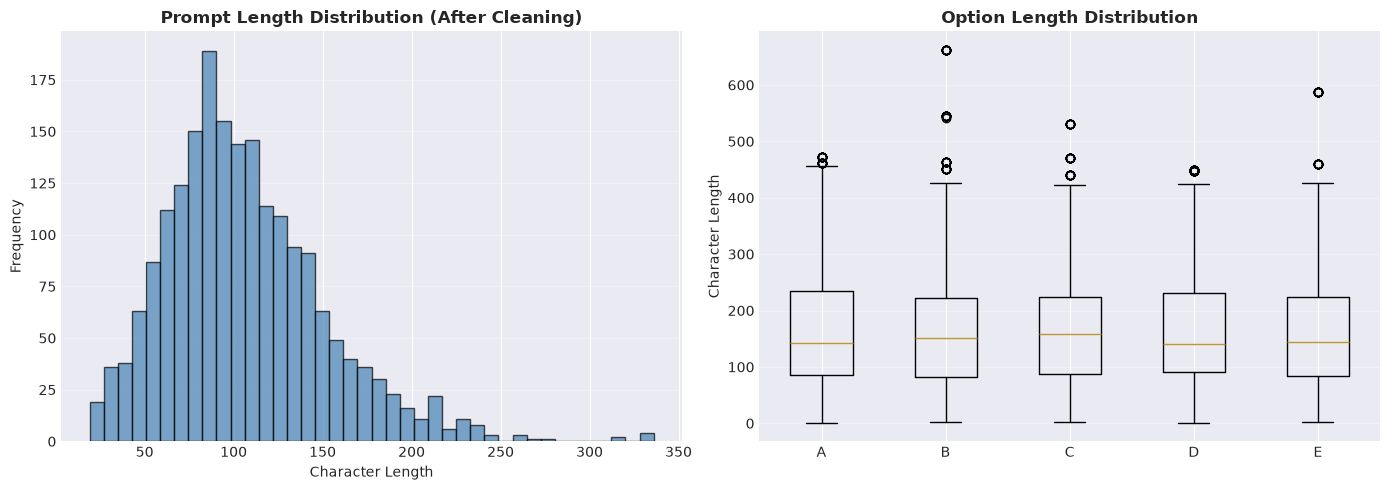

In [10]:
# Visuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prompt length histogram
axes[0].hist(train_clean['prompt_len'], bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Prompt Length Distribution (After Cleaning)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.3)

# Option length box plot
option_lens = [train_clean[f'{col}_len'].values for col in ['A', 'B', 'C', 'D', 'E']]
axes[1].boxplot(option_lens, tick_labels=['A', 'B', 'C', 'D', 'E'])
axes[1].set_title('Option Length Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Character Length')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

TRAIN/VAL SPLIT

In [11]:
# Split parameters
TRAIN_SIZE = 0.8
RANDOM_STATE = 42

# Stratified split (it maintain answer distribution)
np.random.seed(RANDOM_STATE)

In [12]:
train_indices = []
val_indices = []
indices = np.arange(len(train_clean))

In [13]:
# for each answer option, split proportionally
for answer in ['A', 'B', 'C', 'D', 'E']:
    # Get all indices where answer is this option
    answer_mask = train_clean['answer'] == answer
    answer_indices = indices[answer_mask]
    
    # and shuffle them
    np.random.shuffle(answer_indices)
    
    # split proportionally
    n_train = int(len(answer_indices) * TRAIN_SIZE)
    train_indices.extend(answer_indices[:n_train])
    val_indices.extend(answer_indices[n_train:])

In [14]:
# create final train/val dataframes
train_data = train_clean.iloc[train_indices].reset_index(drop=True)
val_data = train_clean.iloc[val_indices].reset_index(drop=True)

split results

In [15]:
print(f"   Train: {len(train_data)} samples ({len(train_data)/len(train_clean)*100:.1f}%)")
print(f"   Val:   {len(val_data)} samples ({len(val_data)/len(train_clean)*100:.1f}%)")

   Train: 1599 samples (80.0%)
   Val:   401 samples (20.1%)


COMBINE PROMPT + OPTIONS

In [16]:
def combine_options(row, separator=" "):
    """
    Combine prompt and all 5 options into single text
    Useful for TF-IDF vectorization and context understanding
    """
    prompt = str(row['prompt'])
    options = [str(row[col]) for col in ['A', 'B', 'C', 'D', 'E']]
    
    # Combine: prompt + all options
    combined = separator.join([prompt] + options)
    return combined

In [17]:
# Create combined text for all datasets
print("Creating combined text for train...")
train_data['combined_text'] = train_data.apply(combine_options, axis=1)

print("Creating combined text for validation...")
val_data['combined_text'] = val_data.apply(combine_options, axis=1)

print("Creating combined text for test...")
test_clean['combined_text'] = test_clean.apply(combine_options, axis=1)

print("\n Combined text created!")

Creating combined text for train...
Creating combined text for validation...
Creating combined text for test...

 Combined text created!


In [18]:
print(f"\n EXAMPLE COMBINED TEXT:")
example = train_data.iloc[0]['combined_text']
print(f"\n{example[:300]}...")


 EXAMPLE COMBINED TEXT:

is correct? which of the following is an accurate definition of dynamic scaling in self-similar frameworks? carefully. dynamic scaling refers to the evolution of self-similar structures, where data obtained from snapshots at fixed times exhibits similarity to the respective data taken from snapshots...


In [19]:
# Length statistics
print(f"\nCOMBINED TEXT LENGTH:")
print(f"   Train avg: {train_data['combined_text'].apply(len).mean():.0f} chars")
print(f"   Val avg:   {val_data['combined_text'].apply(len).mean():.0f} chars")
print(f"   Test avg:  {test_clean['combined_text'].apply(len).mean():.0f} chars")


COMBINED TEXT LENGTH:
   Train avg: 938 chars
   Val avg:   927 chars
   Test avg:  904 chars


SAVE THE PROCESSED DATA

In [20]:
# Create output directory
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# Save as CSV 
print("\n Saving CSV files...")
train_data.to_csv(OUTPUT_DIR / "train_processed.csv", index=False)
val_data.to_csv(OUTPUT_DIR / "val_processed.csv", index=False)
test_clean.to_csv(OUTPUT_DIR / "test_processed.csv", index=False)

print(f" {OUTPUT_DIR / 'train_processed.csv'}")
print(f" {OUTPUT_DIR / 'val_processed.csv'}")
print(f" {OUTPUT_DIR / 'test_processed.csv'}")


 Saving CSV files...
 ../outputs/train_processed.csv
 ../outputs/val_processed.csv
 ../outputs/test_processed.csv


In [21]:
preprocessing_stats = {
    "Original Train Size": f"{len(train_df)}",
    "Train Size (After Split)": f"{len(train_data)}",
    "Validation Size": f"{len(val_data)}",
    "Test Size": f"{len(test_clean)}",
    "Train/Val Ratio": f"{len(train_data)}/{len(val_data)} (80/20)",
    "Prompt Avg Length": f"{train_data['prompt_len'].mean():.0f} chars",
    "Option Avg Length": f"{train_data['A_len'].mean():.0f} chars",
    "Combined Text Avg": f"{train_data['combined_text'].apply(len).mean():.0f} chars",
    "Answer Distribution": "Perfectly Balanced ",
    "Data Quality": "Perfect - No issues ",
}

print("\n KEY STATISTICS:")
for key, value in preprocessing_stats.items():
    print(f"   {key}: {value}")


 KEY STATISTICS:
   Original Train Size: 2000
   Train Size (After Split): 1599
   Validation Size: 401
   Test Size: 500
   Train/Val Ratio: 1599/401 (80/20)
   Prompt Avg Length: 107 chars
   Option Avg Length: 164 chars
   Combined Text Avg: 938 chars
   Answer Distribution: Perfectly Balanced 
   Data Quality: Perfect - No issues 


In [ ]:
###  preprocessing done here now we implement all these in models now i have enough idea about datasets given in this competition...